In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:1690837] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/2006253568/shared_mem_cuda_pool.striatum could be created.
[striatum:1690837] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline
# %load_ext autoreload
# %autoreload 2

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0) * pq.second
ADAPTED_OFFSET = pq.Quantity(-0.5) * pq.second
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.010) * pq.second
EVENTS = {
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}
FREQ_RANGE = (spectrum.THETA_BAND[0], spectrum.GAMMA_BAND[1])
FORCE_RECOMPUTE = False

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
LAMINAE = {
    'L2/3': lambda loc: "2/3" in loc,
    'L4': lambda loc: "4" in loc,
    'L5/6': lambda loc: "5" in loc or "6" in loc,
    'L1/6': lambda loc: "1" in loc or "6" in loc,
}

In [8]:
BANDS = {
    "Theta": spectrum.THETA_BAND,
    "Alpha/Beta": spectrum.ALPHA_BETA_BAND,
    "Gamma": spectrum.LOW_GAMMA_BAND,
}
BAND_NAMES = {
    "Theta": "theta",
    "Alpha/Beta": "alphabeta",
    "Gamma": "gamma"
}
BAND_LATEX = {
    "Theta": "$\\theta$",
    "Alpha/Beta": "$\\alpha/\\beta$",
    "Gamma": "$\\gamma$"
}

In [9]:
AREA_TITLES = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat, layer=None):
    suffix = " (%s)" % layer if layer else ""
    if name in AREA_TITLES:
        return AREA_TITLES[name] + suffix
    return name + suffix
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [10]:
def initialize_spectrum(key, signal, path=None):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0, taper="hann", path=path + "/" + key, time_window=0.200)

In [11]:
def baselined_oscillatory(spectrogram):
    return spectrogram.oscillatory().baseline(-0.250 * pq.second, -0.050 * pq.second, decibels=True)

def oscillatory_oddball(spectrogram):
    return spectrogram[(ODDBALL_ONSET - OFFSET).magnitude:(ODDBALL_OFFSET + OFFSET).magnitude].oscillatory()

In [12]:
spectrograms = {}

In [13]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_spectrogram_downsample4_%s" % cond
    raw_spectrograms = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram).results()
    spectrograms[cond] = raw_spectrograms.smap(oscillatory_oddball)
    del raw_spectrograms
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Loaded LFP spectrograms across condition go_seqctl
INFO:root:Loaded LFP spectrograms across condition lo_gloexp
INFO:root:Loaded LFP spectrograms across condition lo_rndctl
INFO:root:Loaded LFP spectrograms across condition igo_seqctl


In [14]:
PVALUE = 1e-2

In [15]:
CONTRASTS = [("dd", "lo_rndctl", "lonaive"), ("go_contrast", "go_gloexp", "go_seqctl"), ("ssa", "lo_gloexp", "igo_seqctl")]

In [16]:
CONTRAST_TITLES = {
    "go_contrast": "Global Oddball",
    "ssa": "Stimulus Specific Adaptation",
    "dd": "Deviance Detection"
}
CONTRAST_ABBREVS = {"go_contrast": "GO", "ssa": "SSA", "dd": "DD"}
def contrast_stattitle(contrast, name, stat, layer=None):
    suffix = " (%s, %s)" % (CONTRAST_TITLES[contrast], layer) if layer else " (%s)" % CONTRAST_TITLES[contrast]
    return stattitle(name, stat) + suffix

In [17]:
def initialize_grand_cluster_test(key, signals):
    return epych.statistics.grand.GrandNonparametricClusterTest(signals[0].num_channels, len(signals[0].times), alpha=PVALUE, partitions=1000)

In [18]:
contrasts = {}
diffs = {}

In [19]:
def area_name(probe, signals):
    return probe

In [20]:
for (name, condl, condr) in CONTRASTS:
    contrast = epych.statistic.Summary(area_name, initialize_grand_cluster_test)
    contrast._trials = spectrograms[condl]._trials
    contrast_signals = {}
    for k in anatomical_areas:
        contrast_signals[k] = (spectrograms[condl].signals[k].decibels(), spectrograms[condr].signals[k].decibels())
    contrast.calculate([contrast_signals])

    if os.path.exists("/mnt/data/000253/oscillatory_contrasts_" + name + '_01') and not FORCE_RECOMPUTE:
        diffs[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_diffs_" + name + '_01')
        contrasts[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_contrasts_" + name + '_01')
    else:
        area_contrasts = contrast.results()
        diffs[name] = epych.recording.EvokedSampling(epych.recording.empty_intervals(), epych.recording.empty_trials(), epych.recording.default_units(), **{
            k: v['signal'] for k, v in area_contrasts.items()
        })
        diffs[name].pickle("/mnt/data/000253/oscillatory_diffs_" + name + '_01')
    
        contrasts[name] = diffs[name].smap(lambda k, sig: sig.fmap(lambda data: data * area_contrasts[k]['mask']), keys=True)
        contrasts[name].pickle("/mnt/data/000253/oscillatory_contrasts_" + name + '_01')

    logging.info("Nonparametrically contrasted spectrograms for %s" % name)

INFO:root:Nonparametrically contrasted spectrograms for dd
INFO:root:Nonparametrically contrasted spectrograms for go_contrast
INFO:root:Nonparametrically contrasted spectrograms for ssa


In [21]:
CONTRAST_VMAXES = {
    "dd": {
        "All": 2.,
        "Theta": 2.5,
        "Alpha/Beta": 2.5,
        "Gamma": 2.5,
    },
    "go_contrast": {
        "All": 0.6,
        "Theta": 1.5,
        "Alpha/Beta": 1.5,
        "Gamma": 1.5,
    },
    "ssa": {
        "All": 2.,
        "Theta": 2.5,
        "Alpha/Beta": 2.5,
        "Gamma": 2.5,
    },
}

In [22]:
def superficial(tfr_summary, l1=False):
    selector = lambda loc: "2/3" in loc
    if l1:
        selector = lambda loc: selector(loc) or "1" in loc
    return tfr_summary.smap(lambda tfr: tfr.select_channels([selector(loc) for loc in tfr.channels.location]))

def deep(tfr_summary):
    return tfr_summary.smap(lambda tfr: tfr.select_channels(["5" in loc or "6" in loc for loc in tfr.channels.location]))

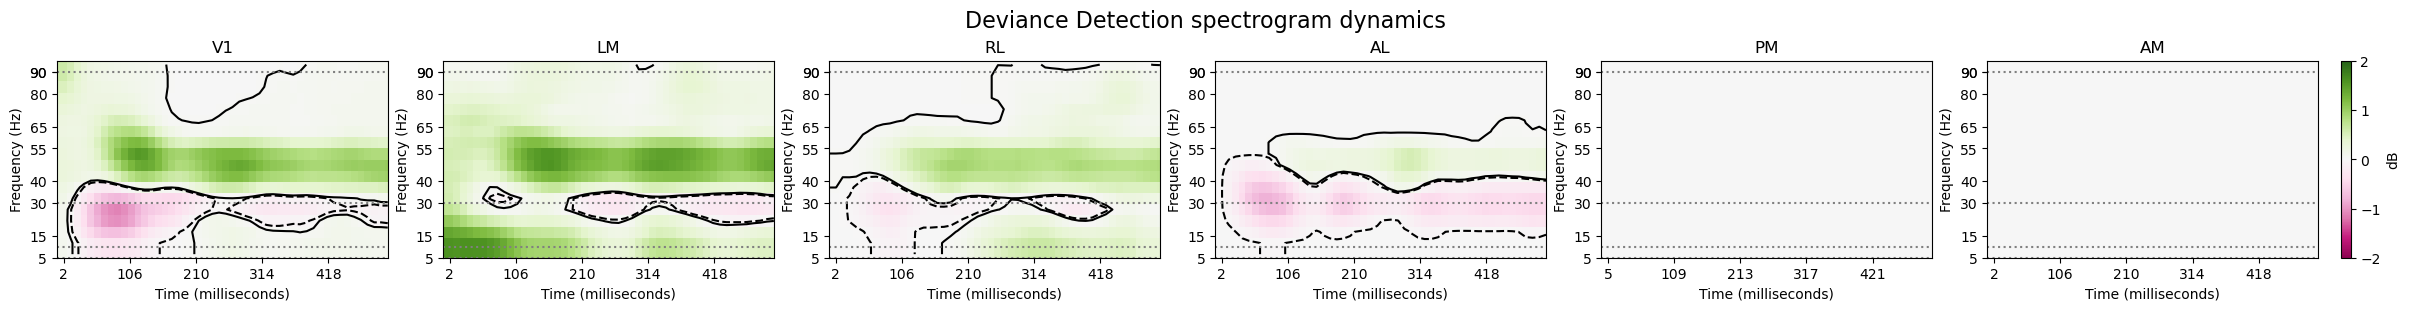

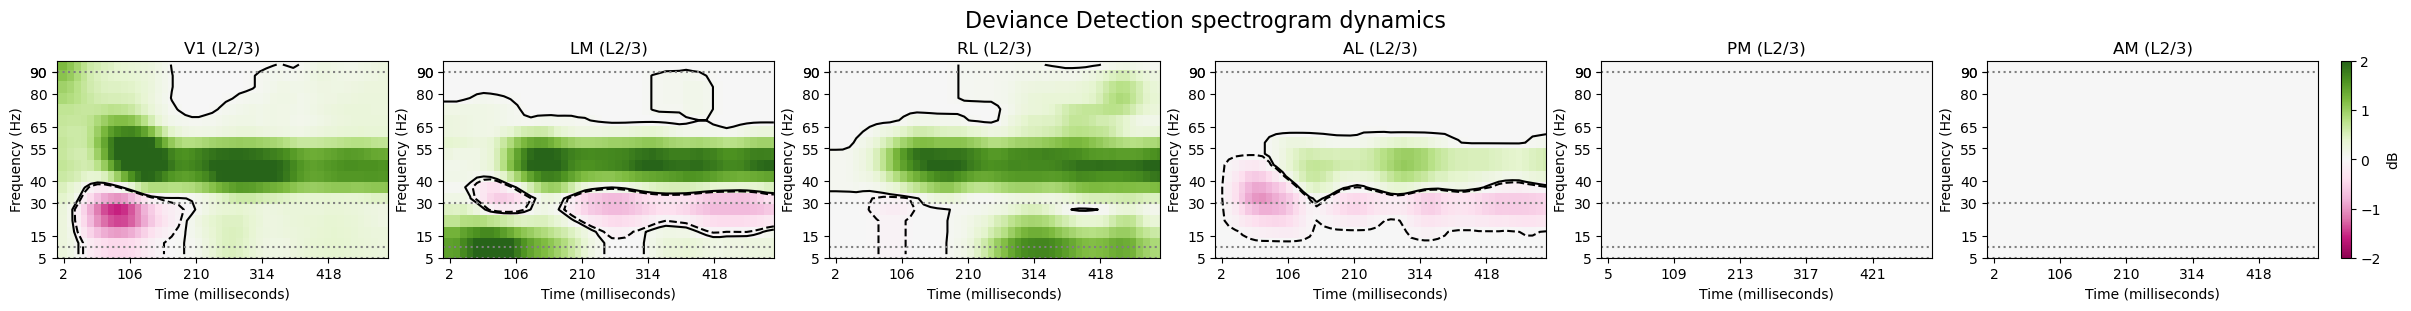

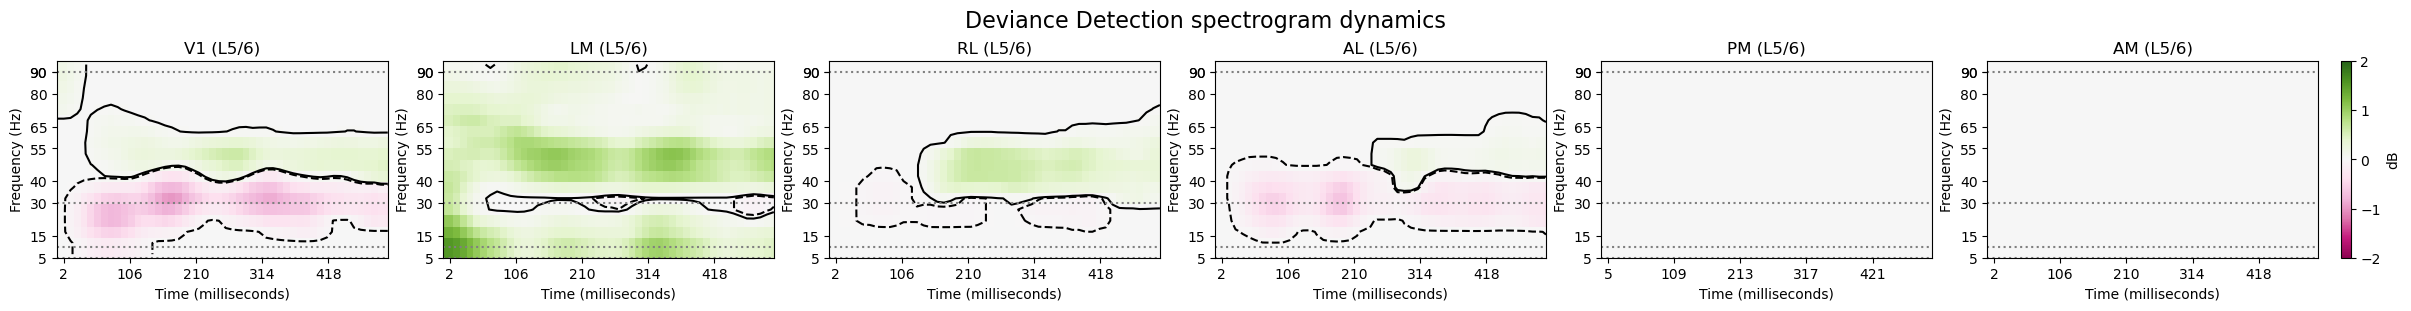

INFO:root:dd in area VISp had 19 channels


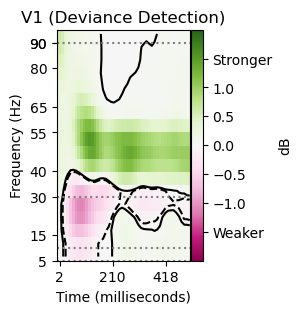

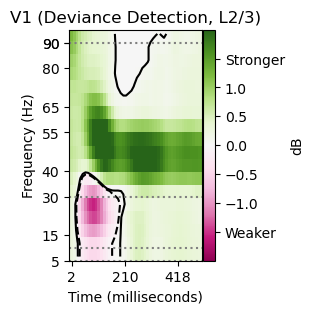

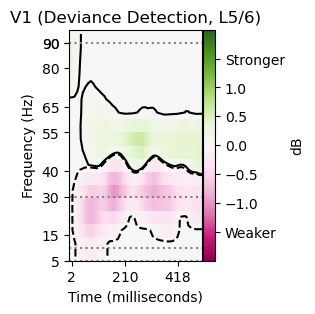

INFO:root:dd in area VISl had 20 channels


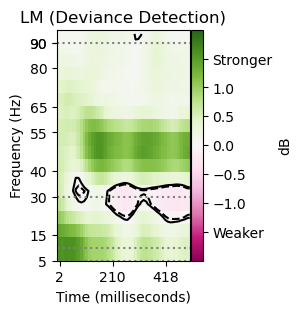

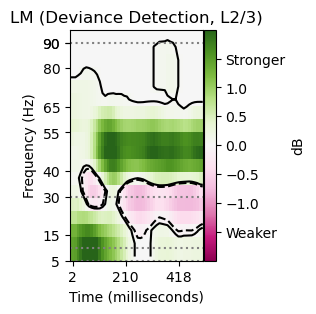

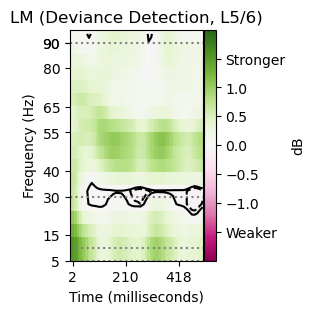

INFO:root:dd in area VISrl had 17 channels


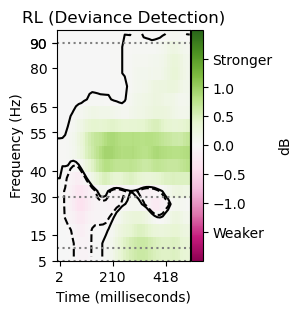

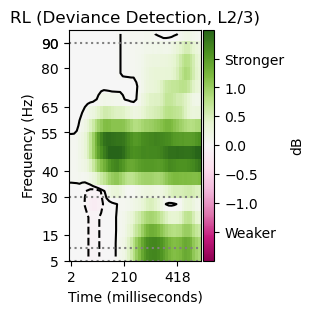

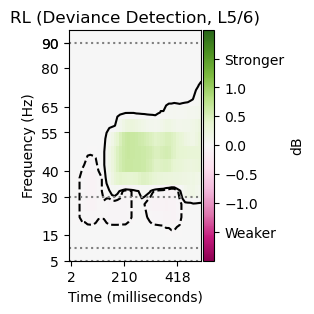

INFO:root:dd in area VISal had 15 channels


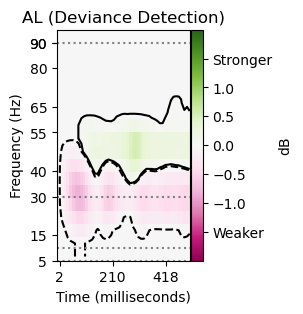

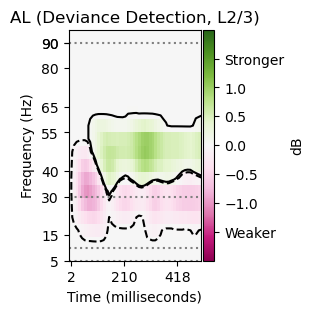

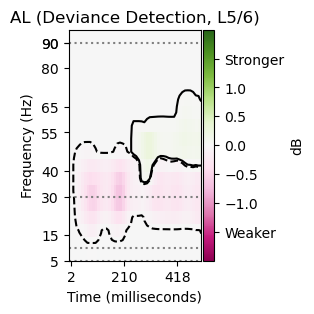

INFO:root:dd in area VISpm had 18 channels


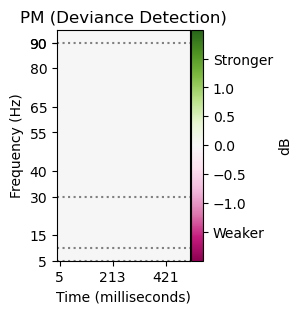

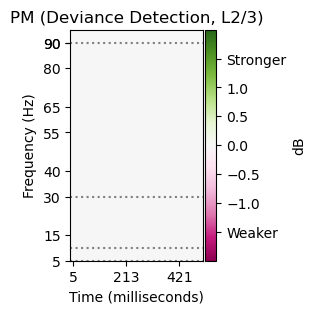

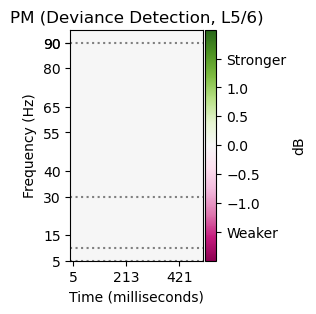

INFO:root:dd in area VISam had 16 channels


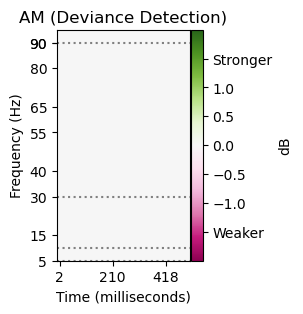

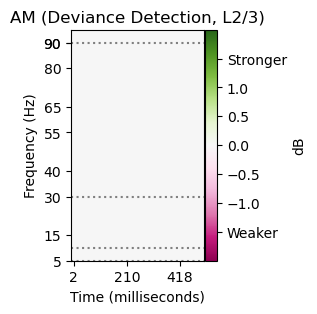

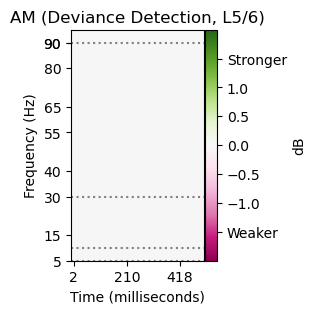

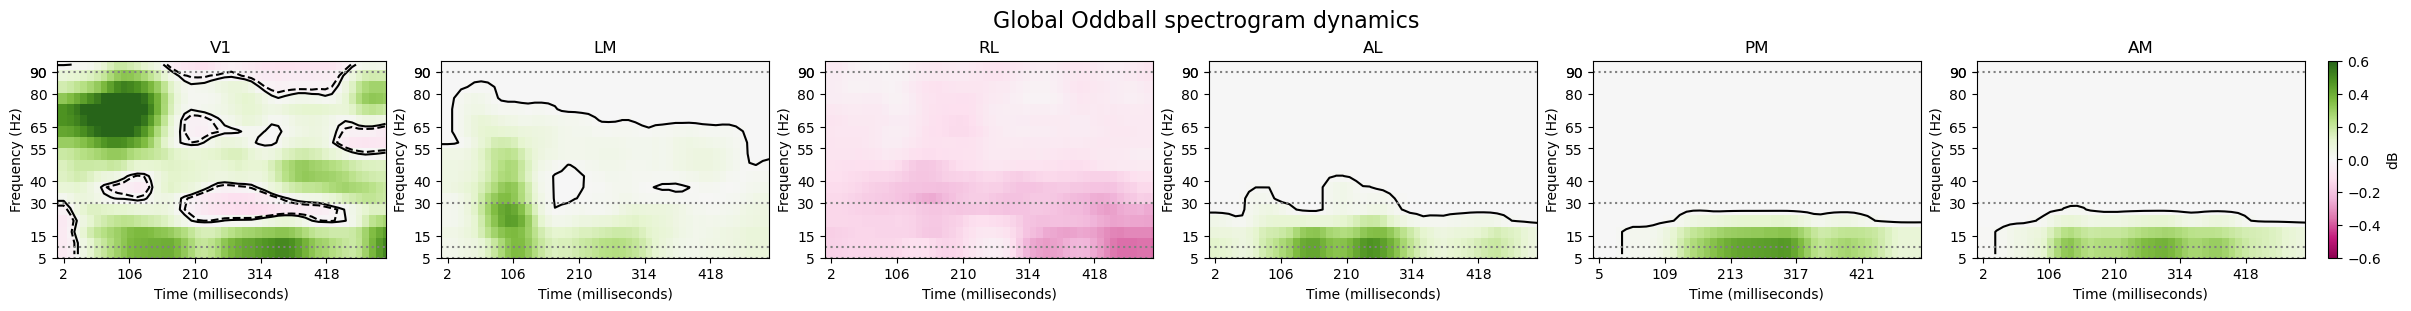

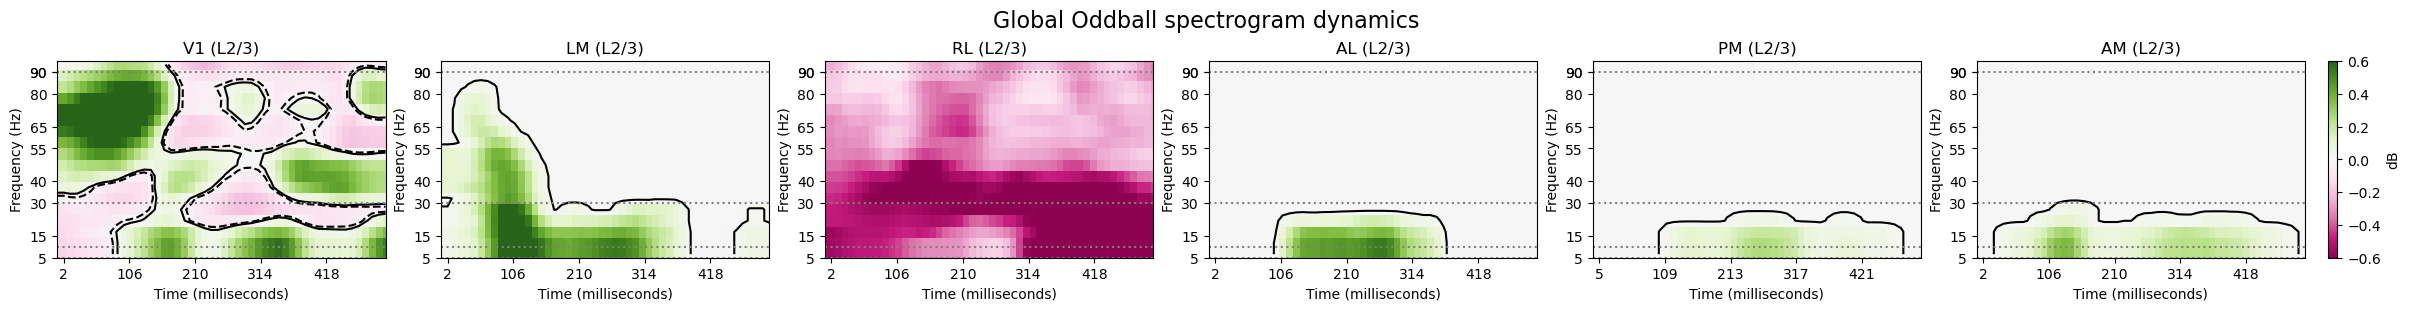

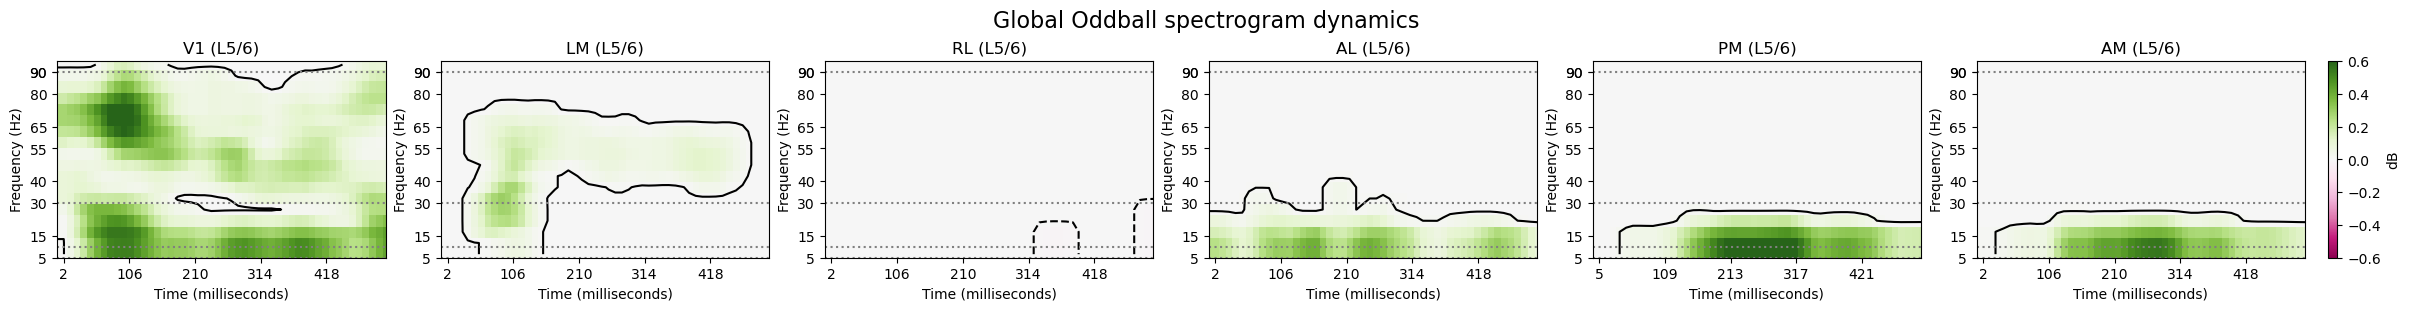

INFO:root:go_contrast in area VISp had 19 channels


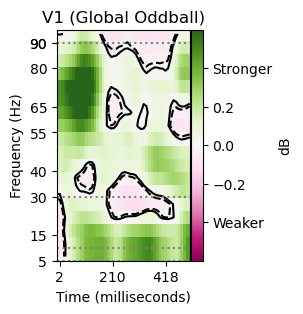

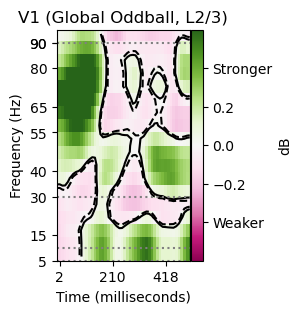

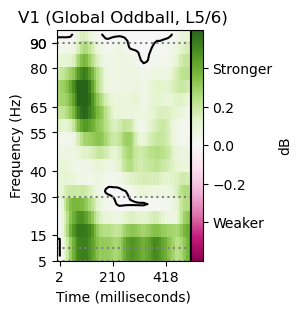

INFO:root:go_contrast in area VISl had 20 channels


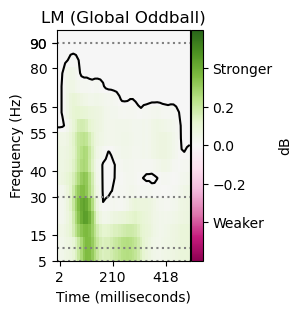

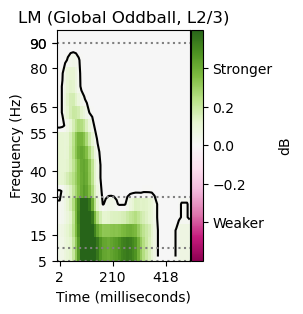

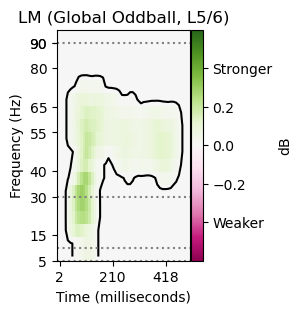

INFO:root:go_contrast in area VISrl had 17 channels


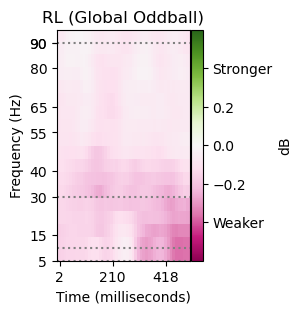

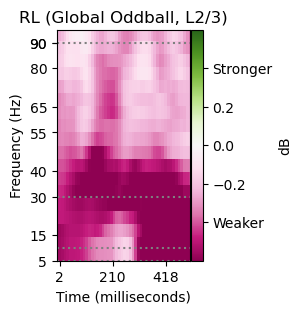

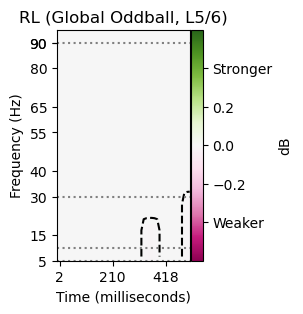

INFO:root:go_contrast in area VISal had 15 channels


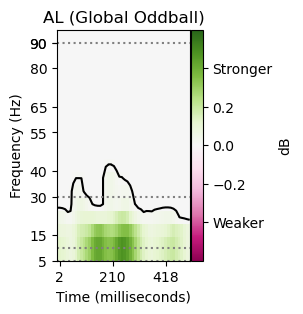

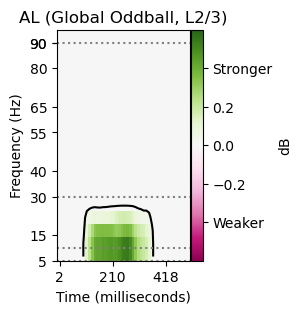

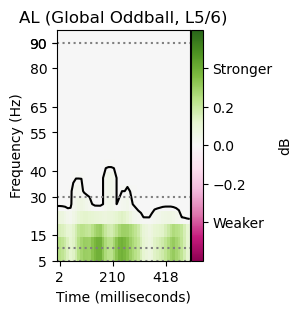

INFO:root:go_contrast in area VISpm had 18 channels


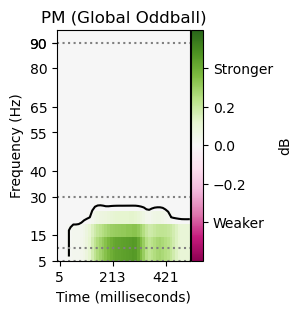

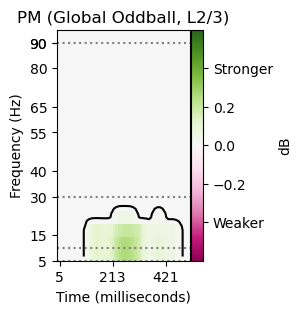

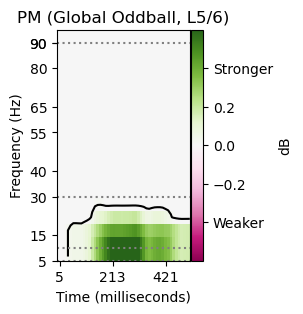

INFO:root:go_contrast in area VISam had 16 channels


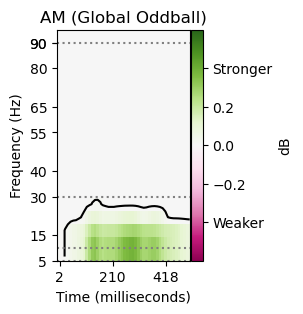

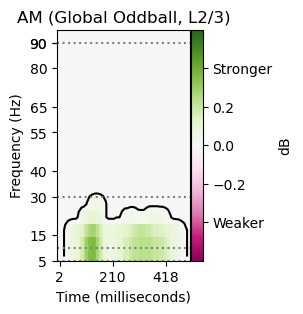

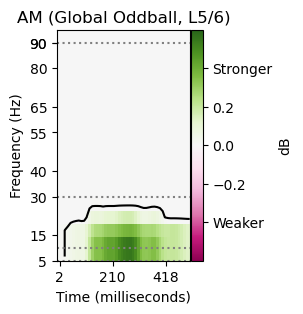

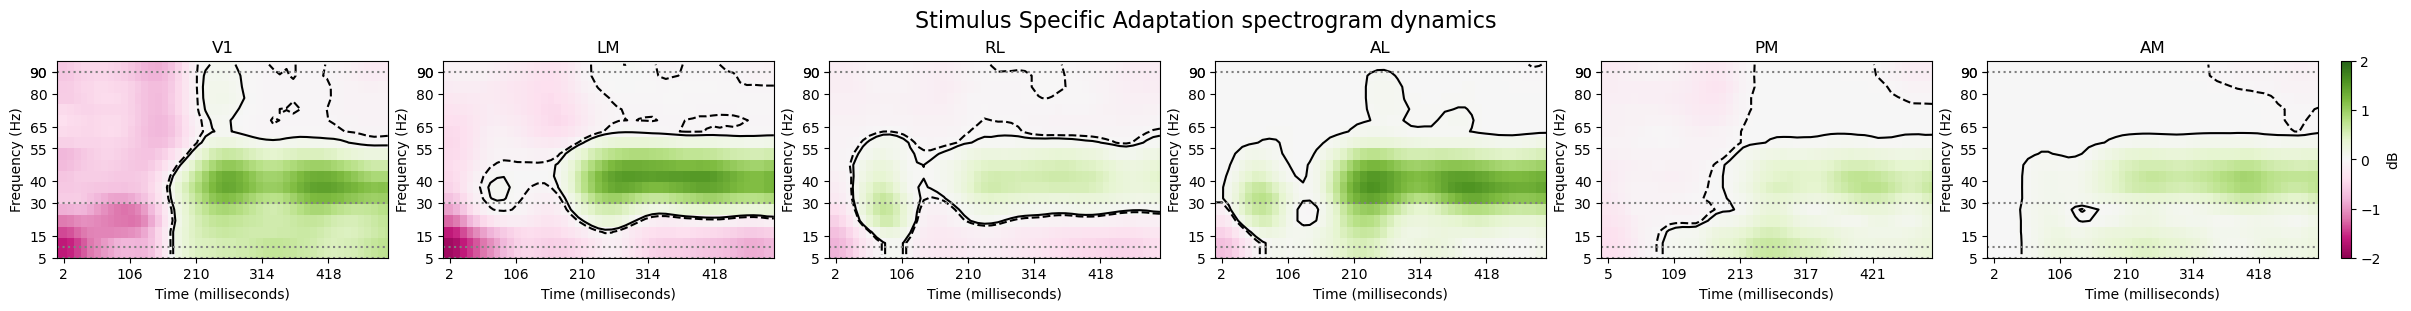

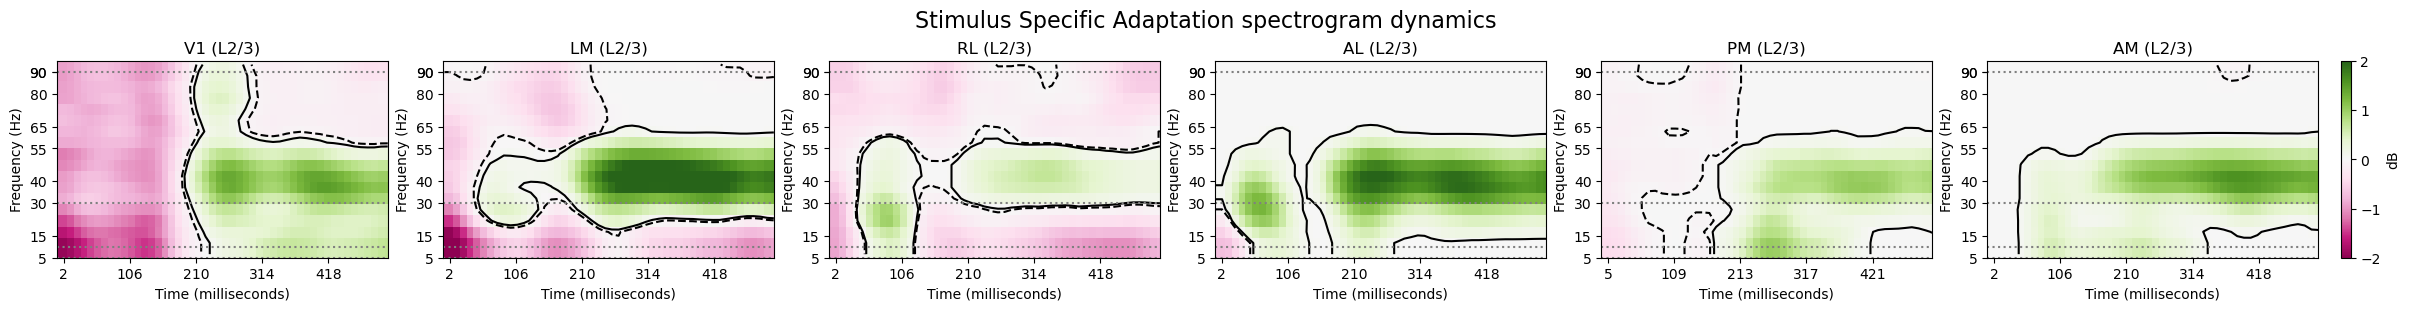

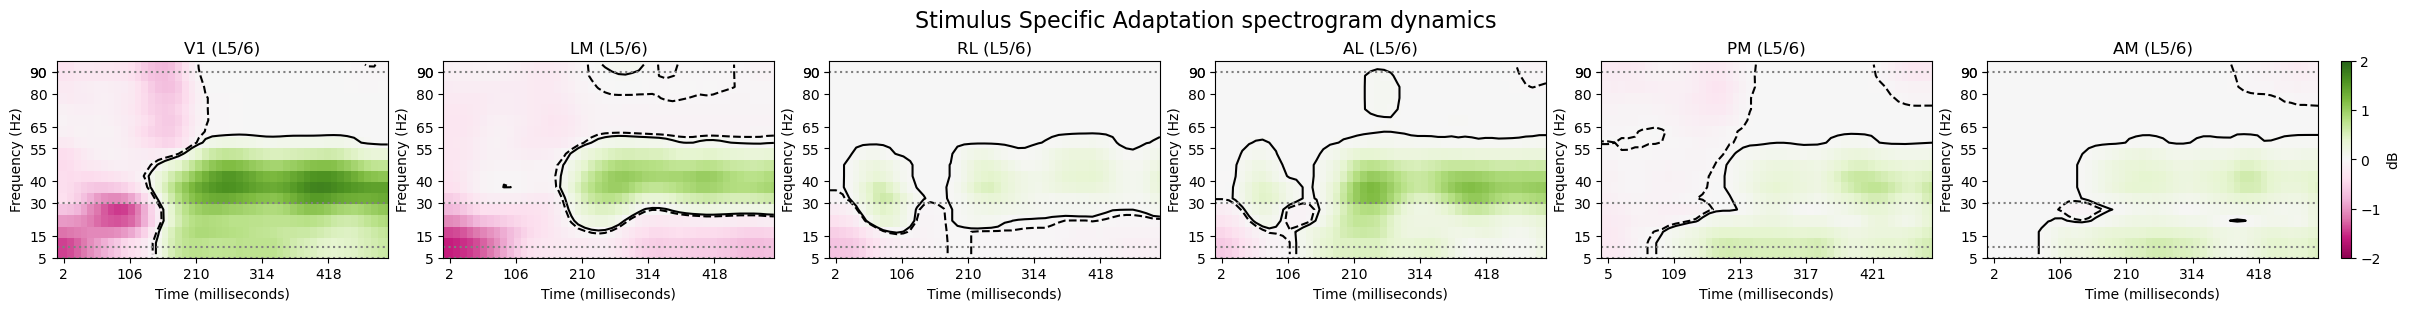

INFO:root:ssa in area VISp had 19 channels


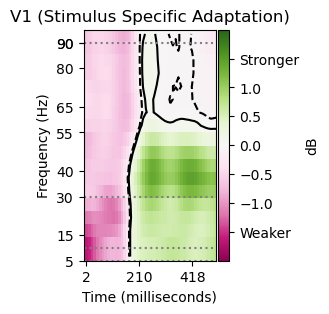

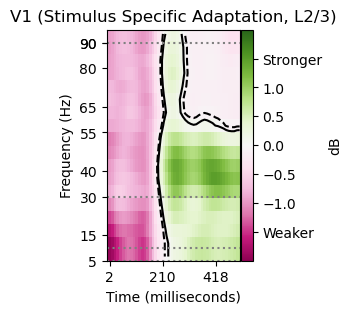

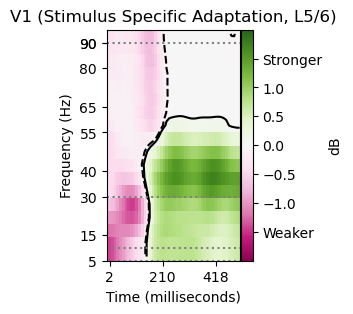

INFO:root:ssa in area VISl had 20 channels


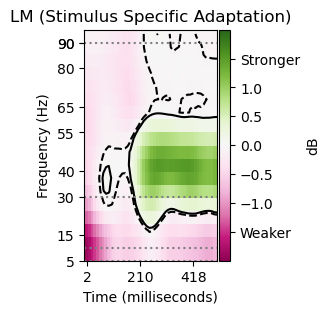

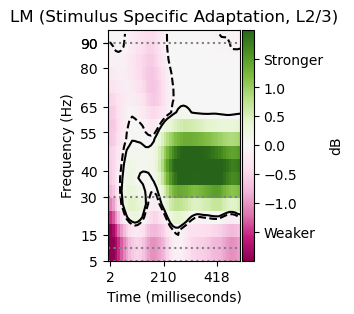

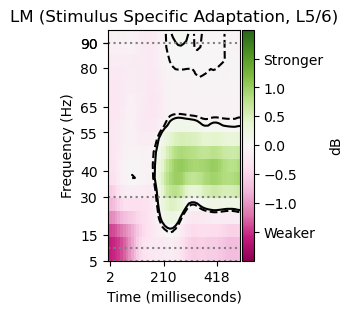

INFO:root:ssa in area VISrl had 17 channels


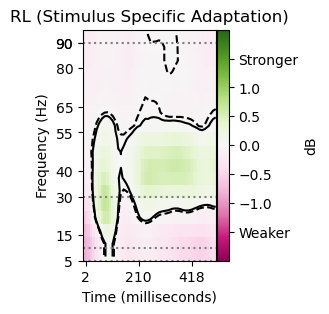

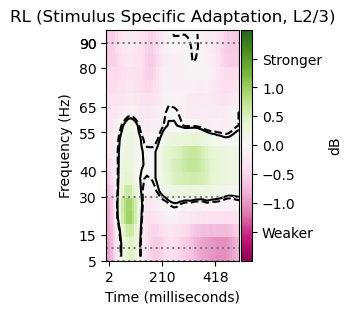

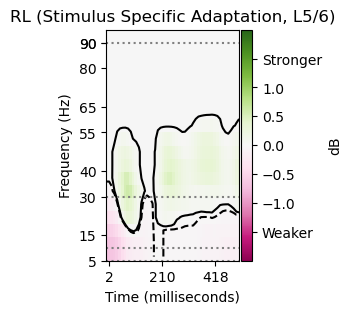

INFO:root:ssa in area VISal had 15 channels


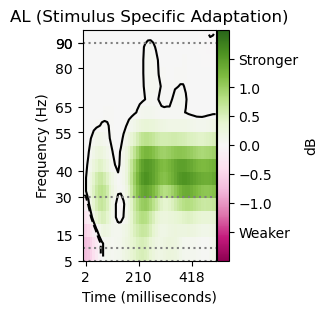

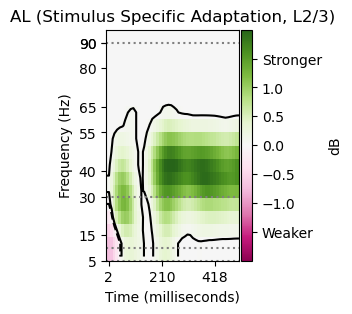

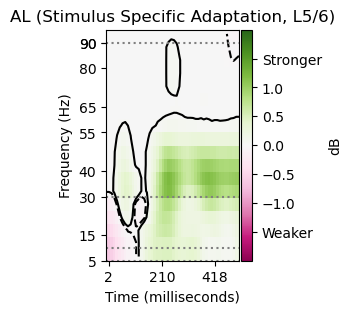

INFO:root:ssa in area VISpm had 18 channels


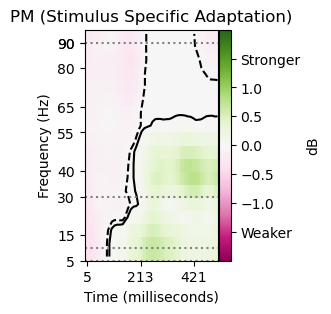

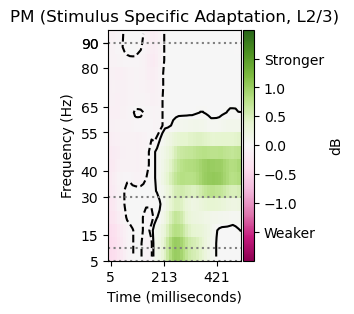

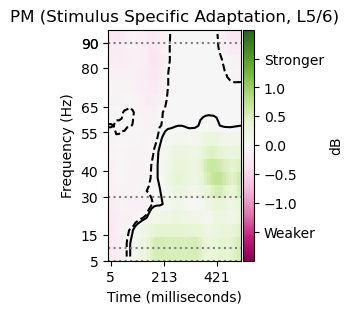

INFO:root:ssa in area VISam had 16 channels


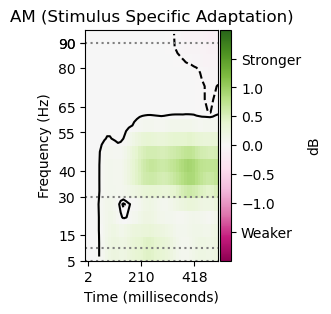

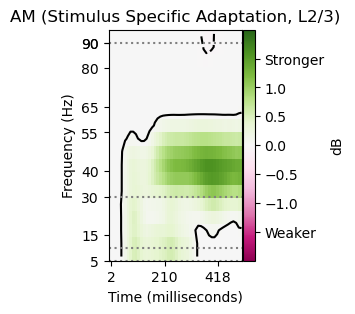

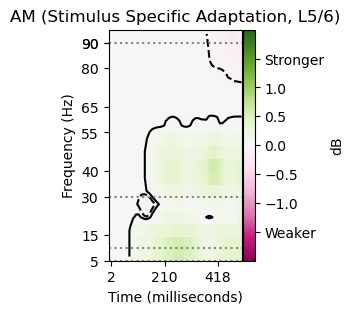

In [23]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp().smap(lambda sig: sig.select_freqs(*FREQ_RANGE))
    contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer=None), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                  title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_01.svg" % name, contours=True)
    
    superficial_contrast = superficial(contrast)
    superficial_contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer='L2/3'), cmap='PiYG',
                              vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"], contours=True,
                              title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_L23_01.svg" % name)

    deep_contrast = deep(contrast)
    deep_contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer='L5/6'), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                       title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_contrasts_%s_L56_01.svg" % name, contours=True)
    for area in anatomical_areas:
        os.makedirs("oscillatory_contrasts_%s_01/" % name, exist_ok=True)
        logging.info("%s in area %s had %d channels" % (name, area, len(contrast.signals[area].channels)))

        contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer=None), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                                    filename="oscillatory_contrasts_%s_01/%s_oddball.svg" % (name, area), cbar_ends=("Stronger", "Weaker"), contours=True)

        superficial_contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer="L2/3"), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                                                filename="oscillatory_contrasts_%s_01/%s_L23_oddball.svg" % (name, area), cbar_ends=("Stronger", "Weaker"), contours=True)

        deep_contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer="L5/6"), cmap='PiYG', vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                                         filename="oscillatory_contrasts_%s_01/%s_L56_oddball.svg" % (name, area), cbar_ends=("Stronger", "Weaker"), contours=True)

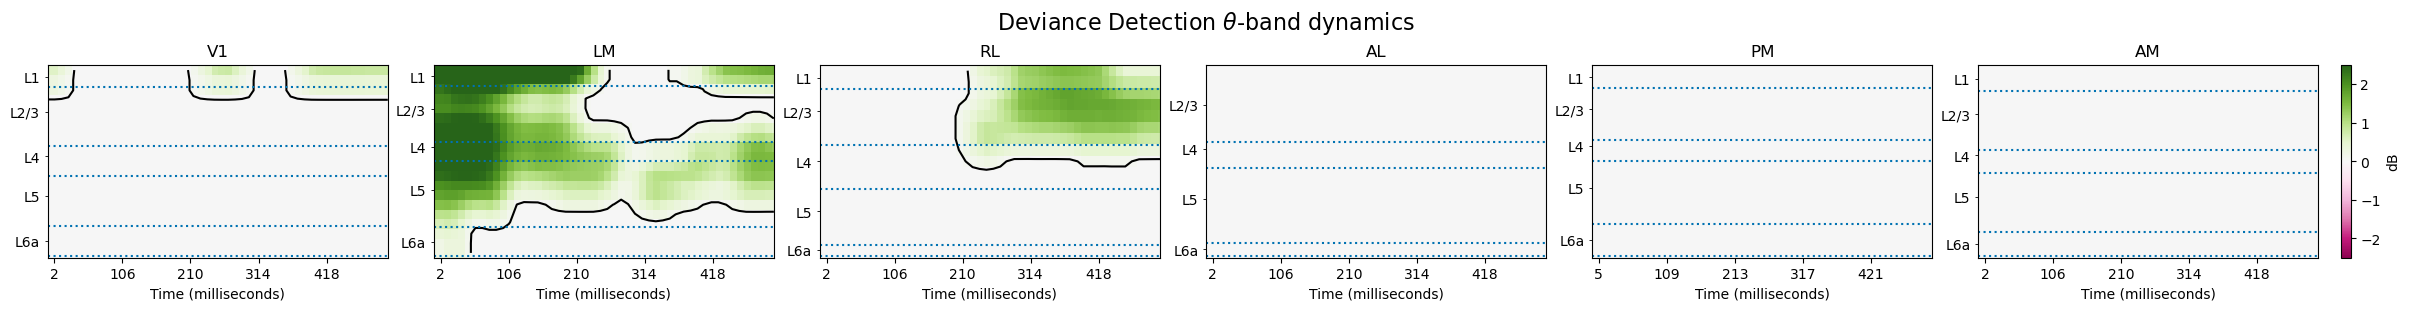

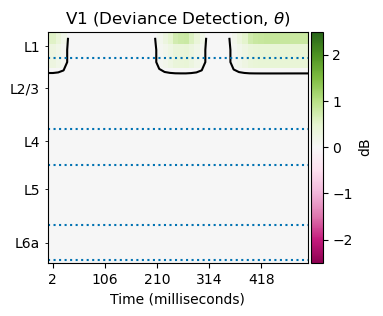

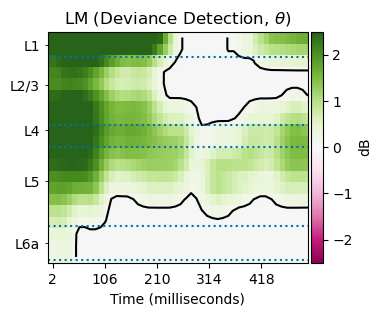

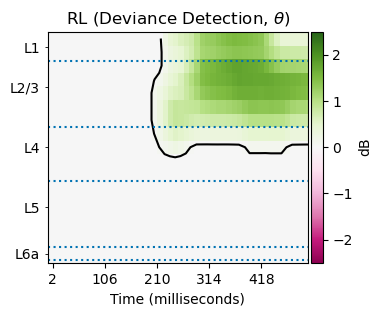

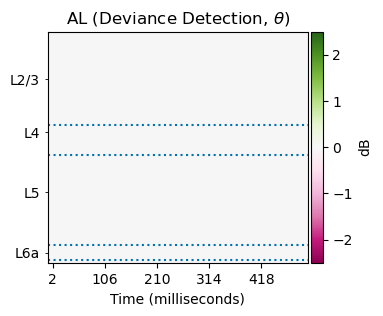

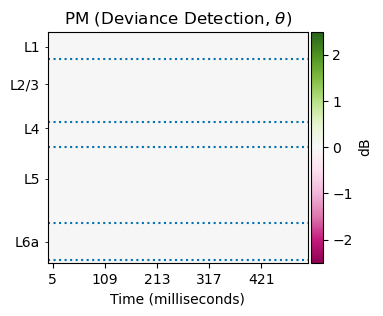

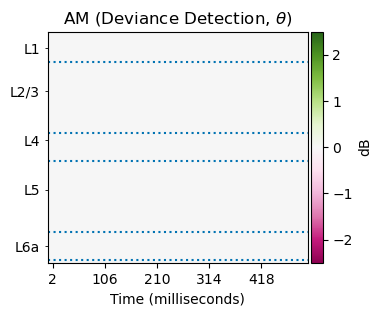

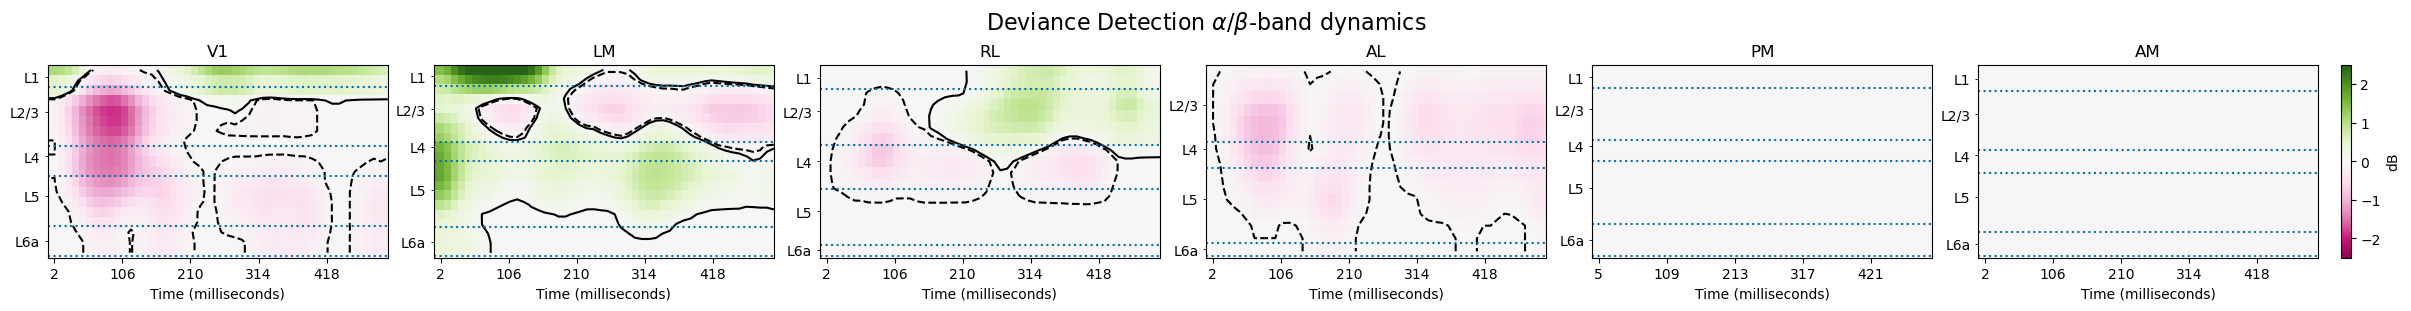

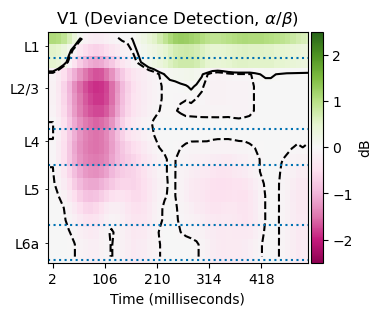

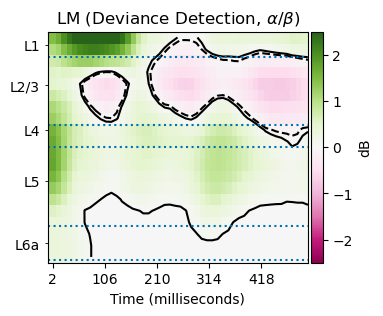

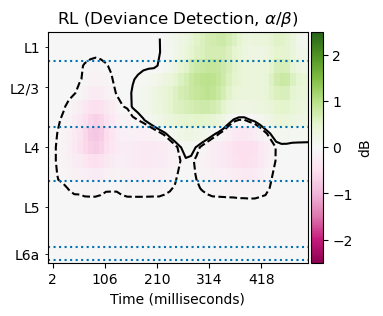

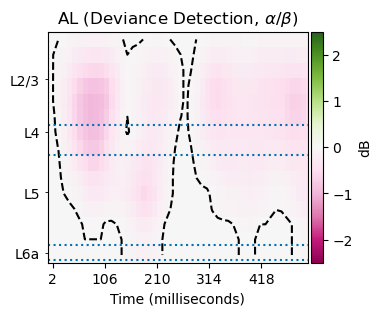

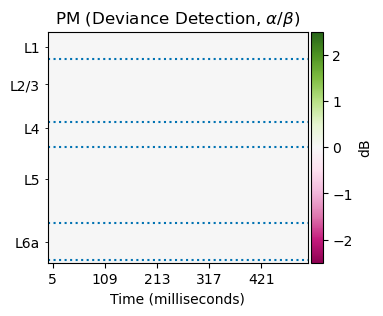

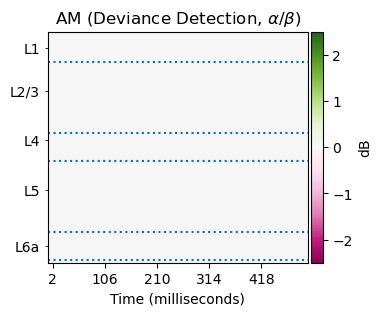

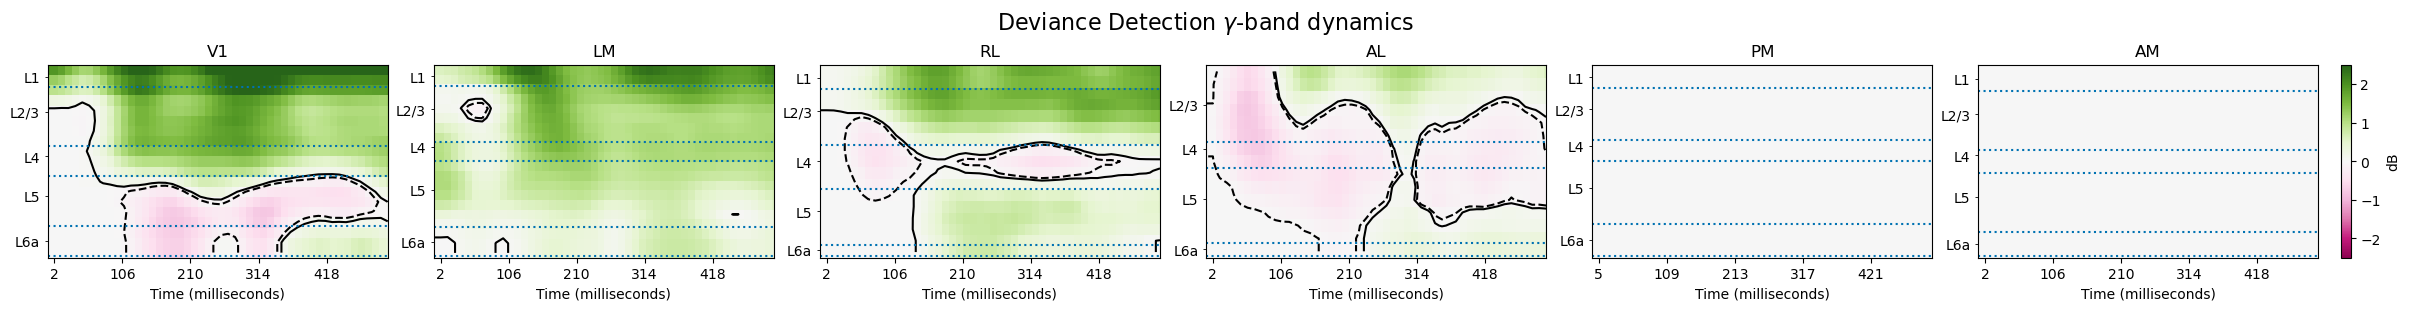

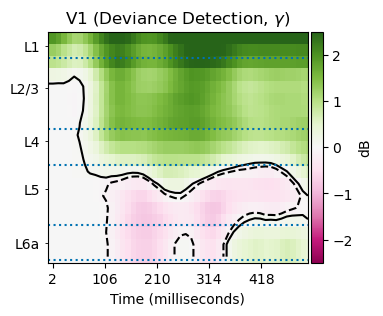

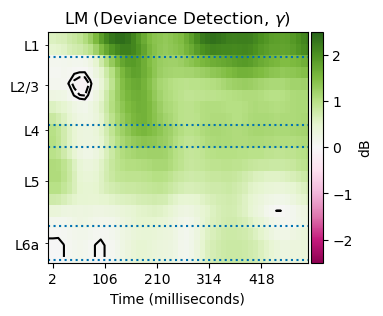

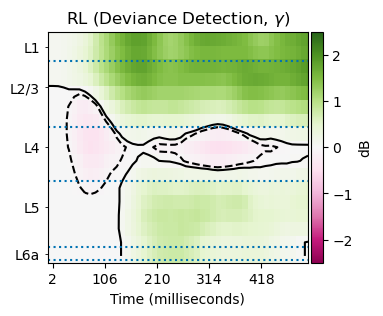

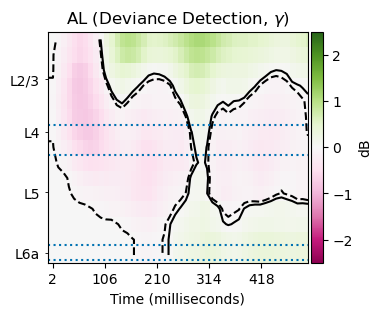

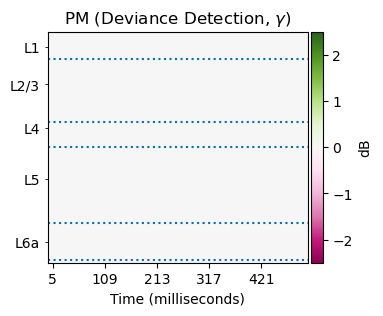

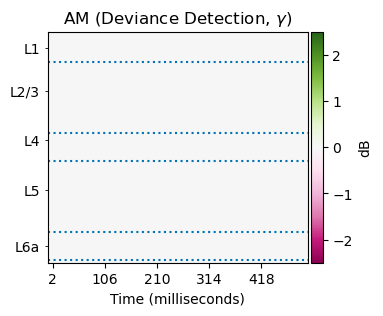

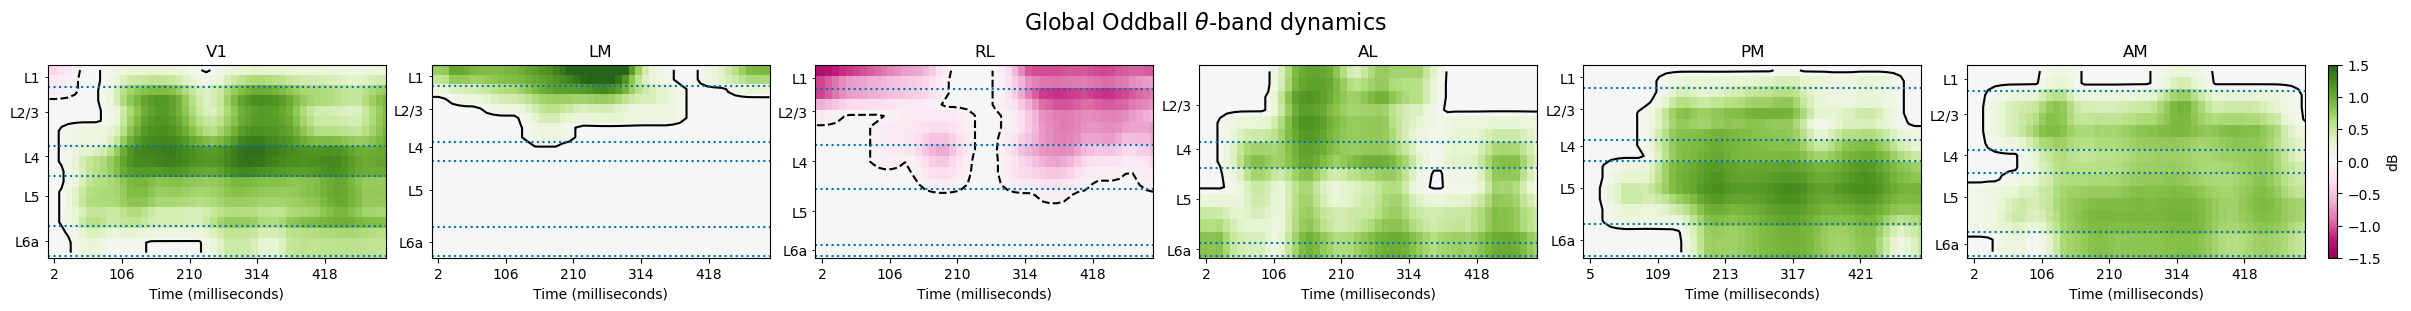

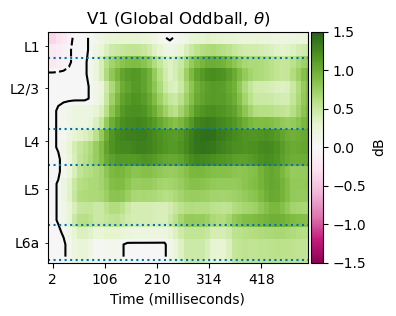

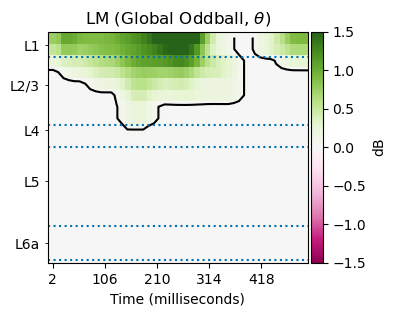

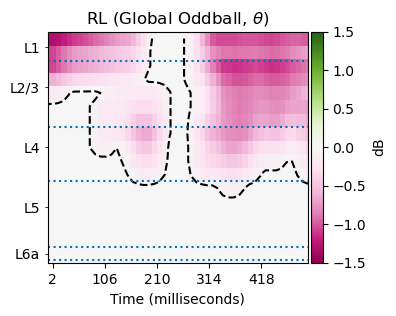

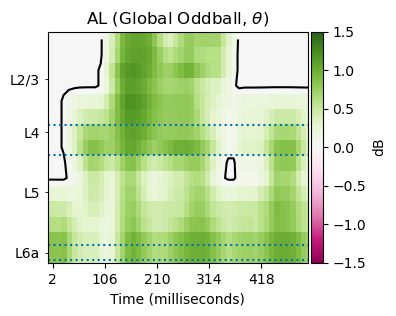

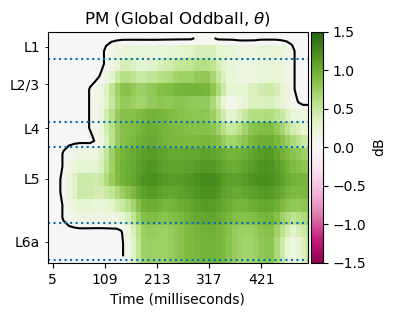

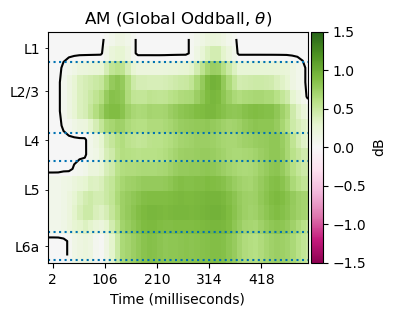

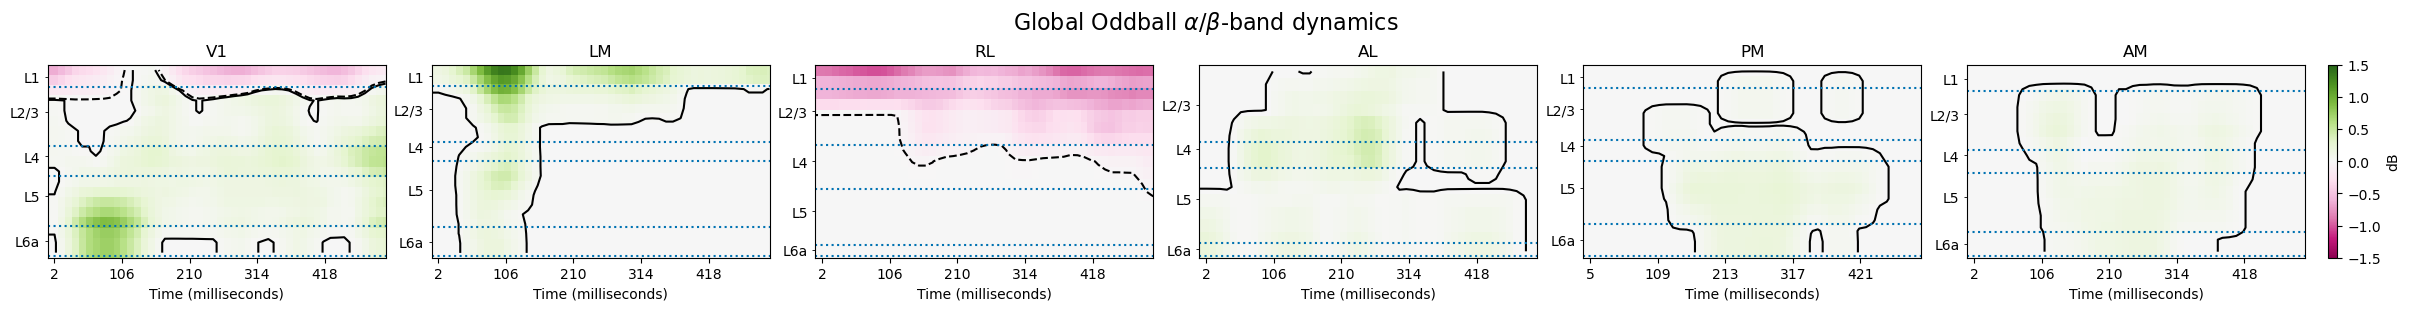

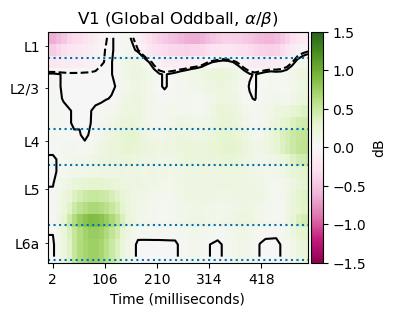

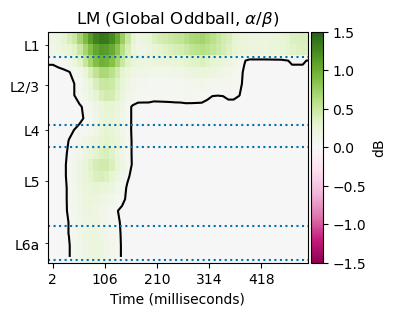

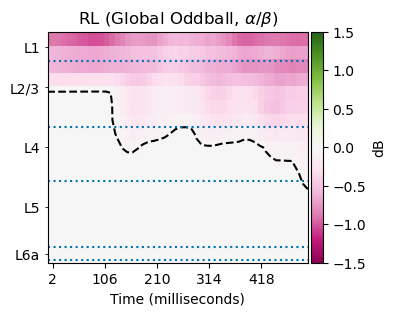

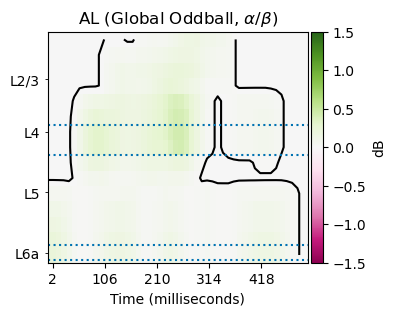

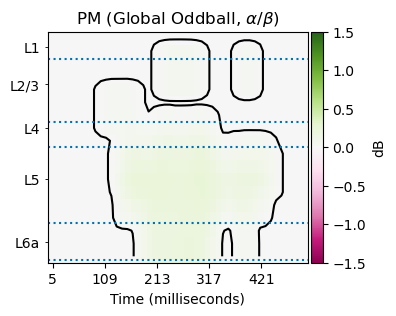

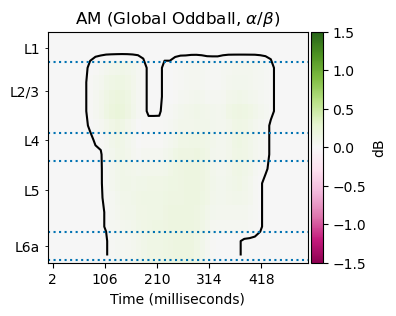

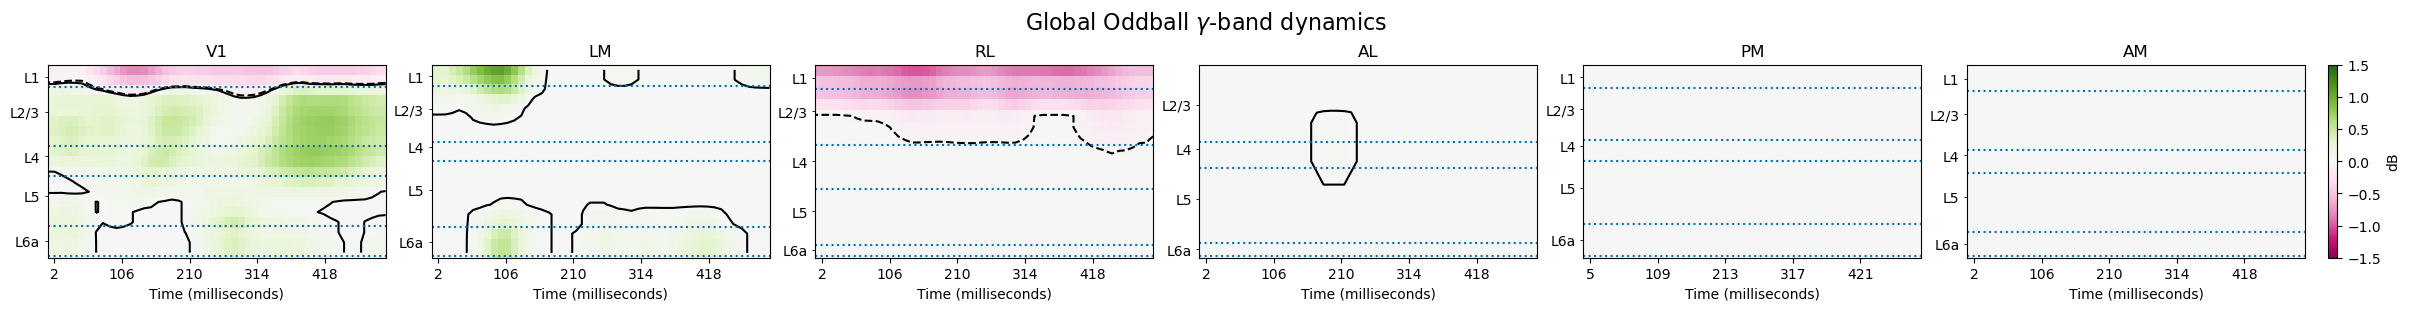

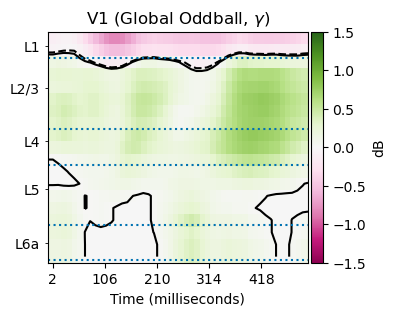

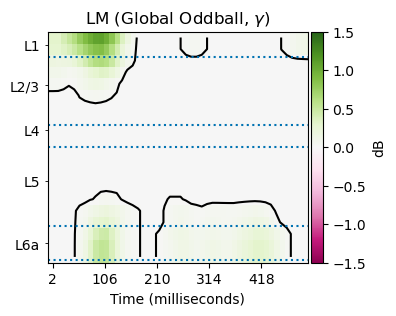

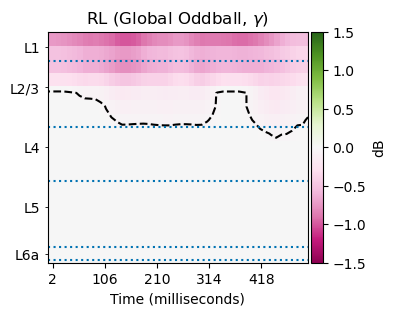

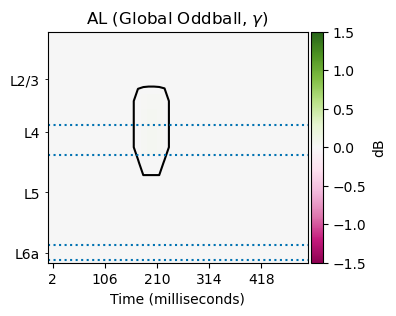

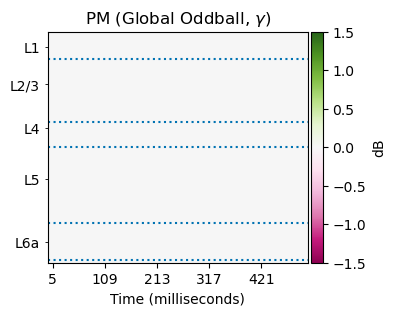

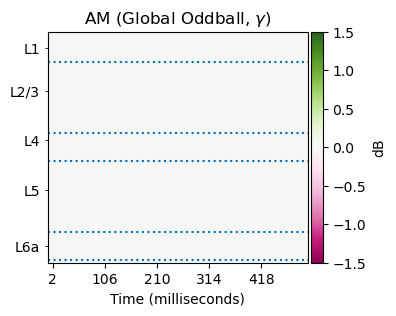

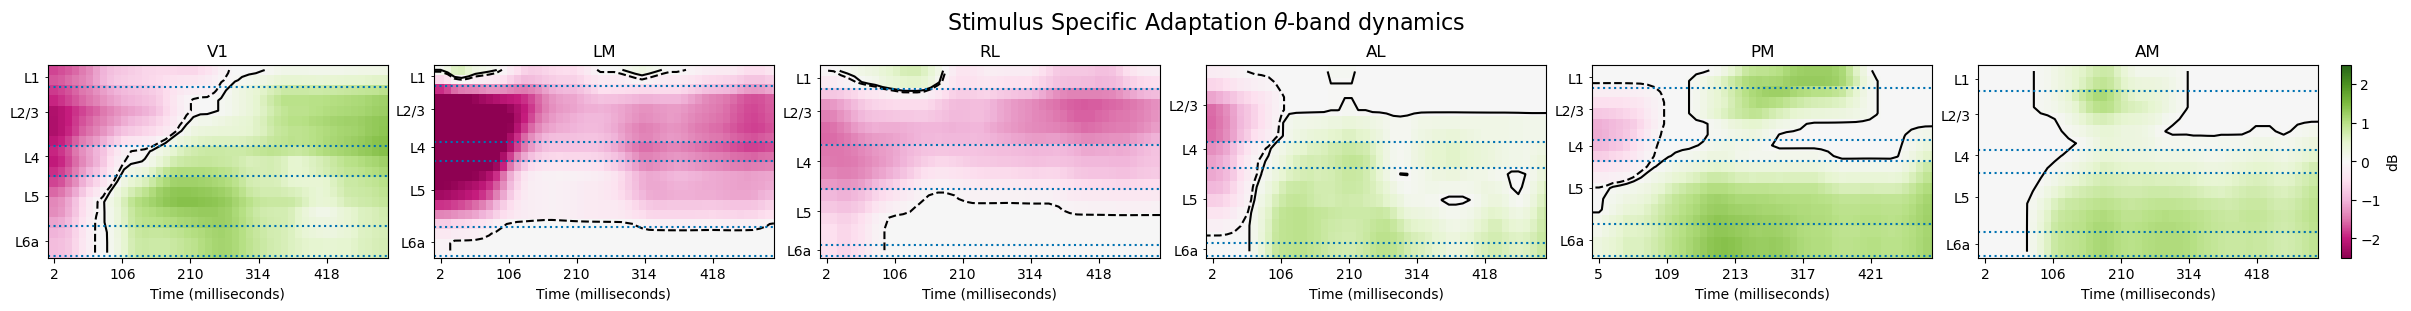

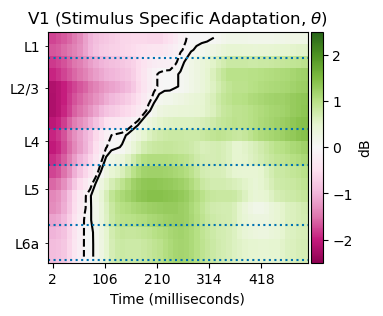

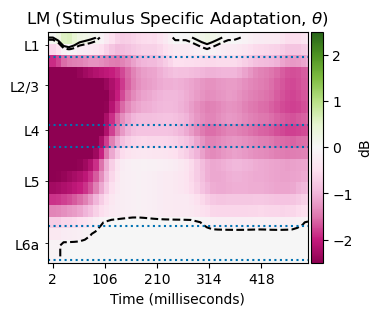

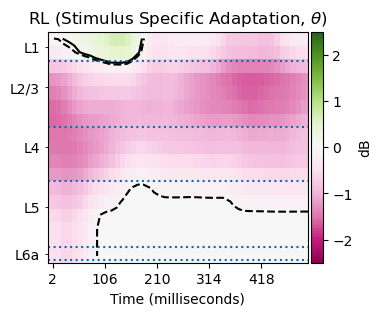

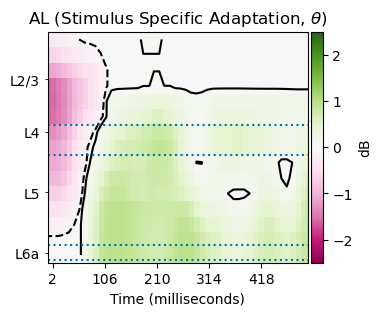

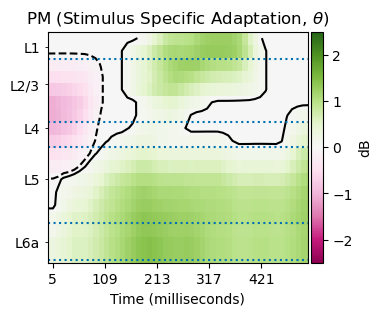

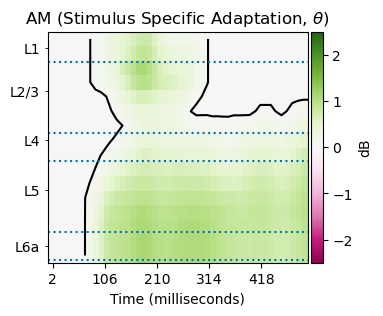

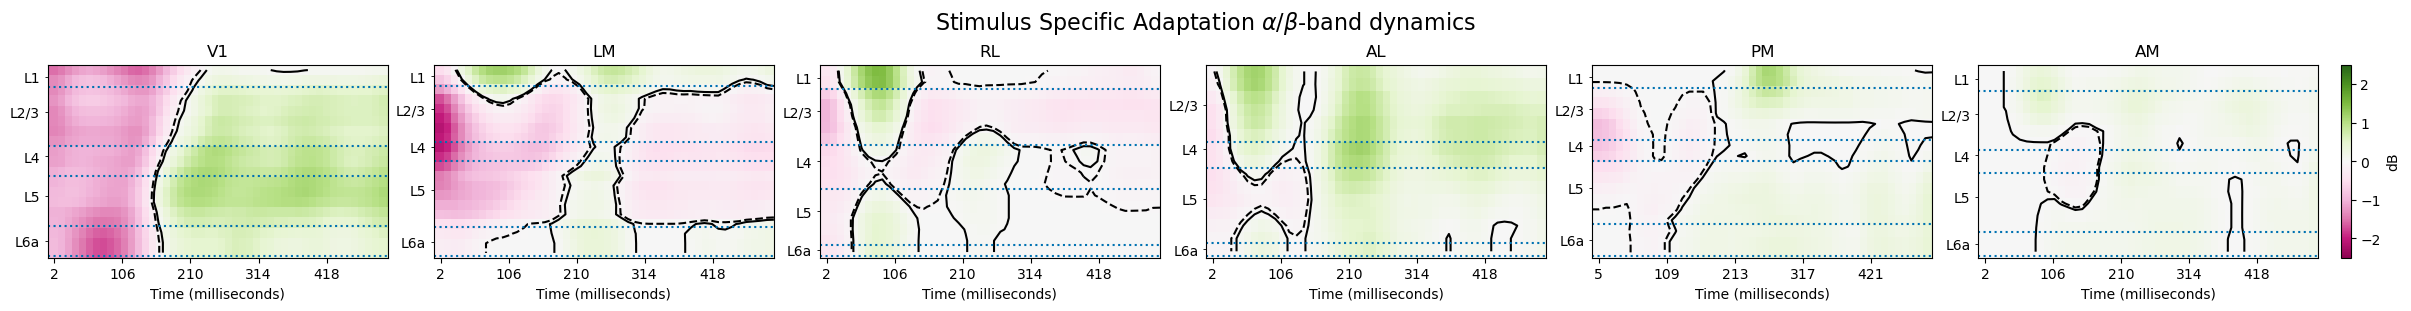

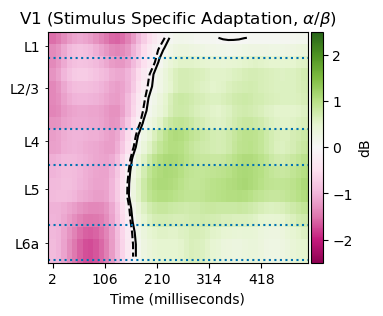

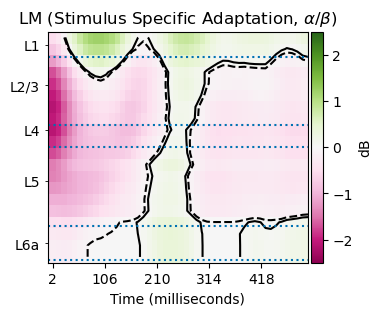

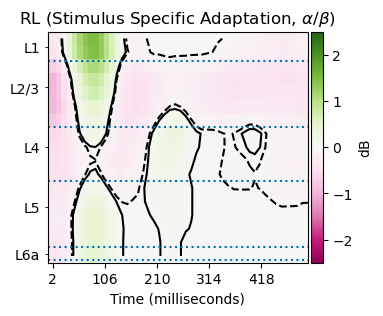

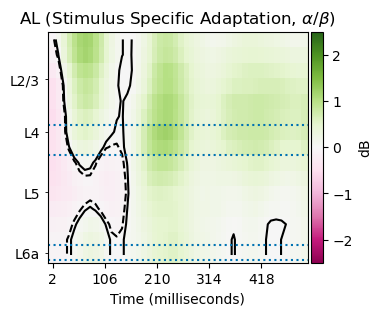

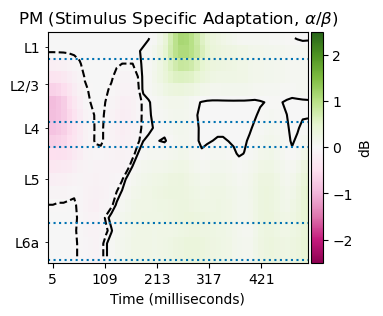

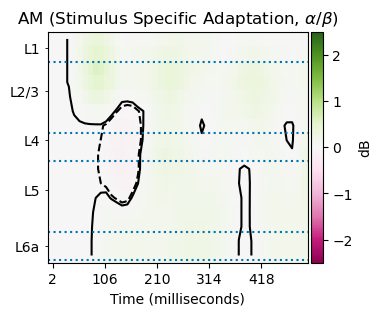

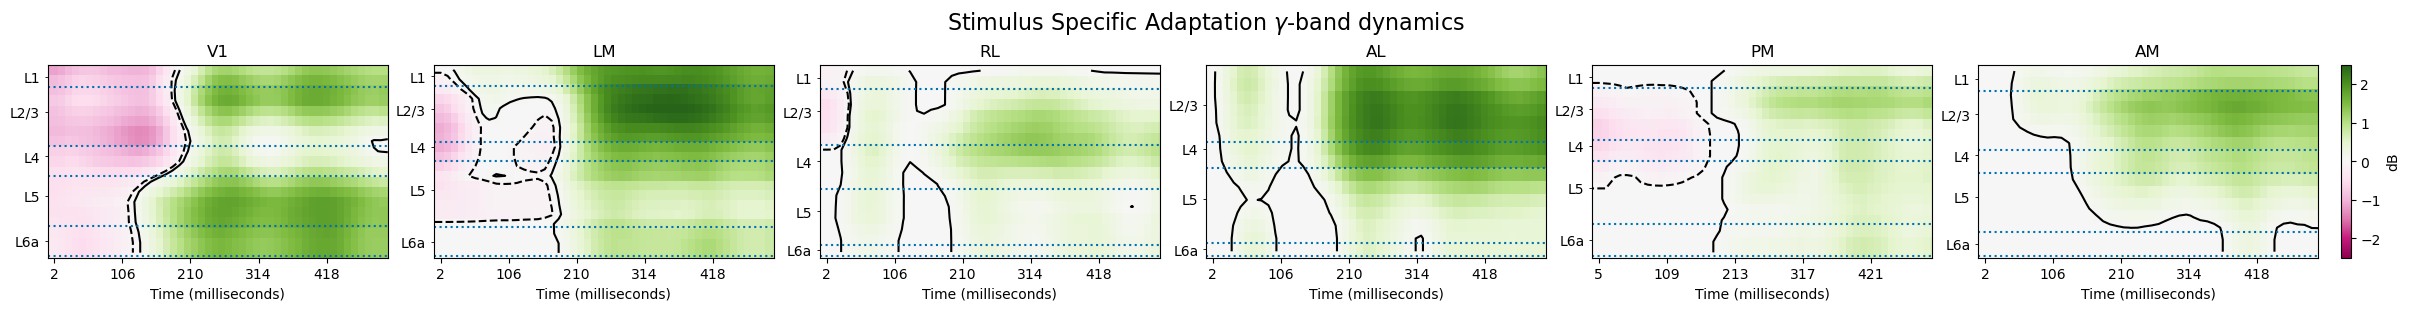

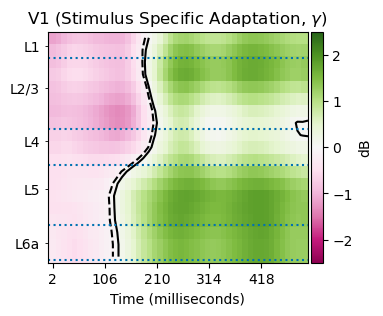

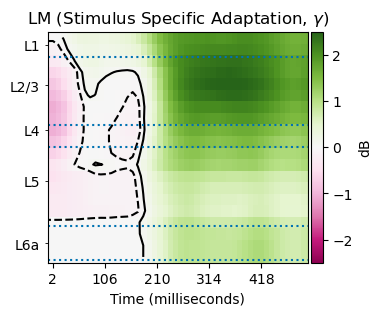

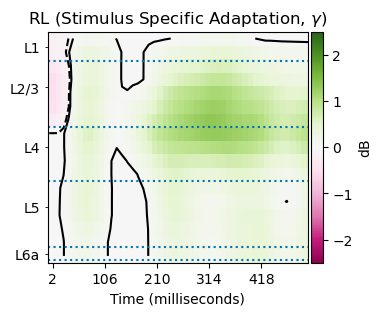

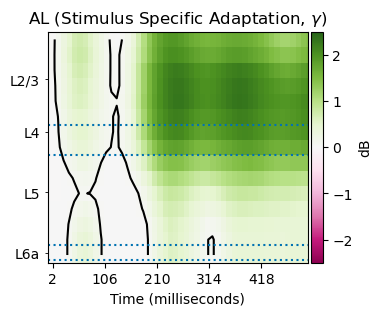

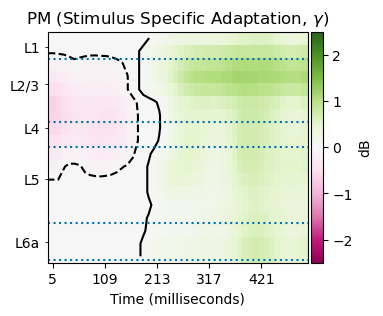

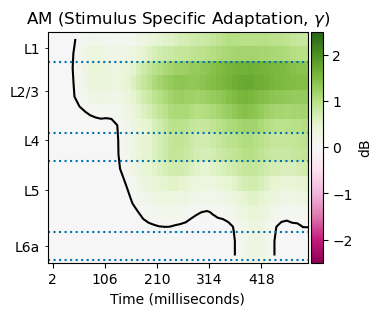

In [24]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp()

    for band, freqs in BANDS.items():
        band_powers = contrast.smap(lambda tfr: tfr.band_power(freqs[0], freqs[1]))
        band_powers.plot(signals=anatomical_areas, sigtitle=stattitle, vmin=-CONTRAST_VMAXES[name][band], vmax=CONTRAST_VMAXES[name][band],
                         title="%s %s-band dynamics" % (CONTRAST_TITLES[name], BAND_LATEX[band]), cmap='PiYG', contours=True,
                         figure="oscillatory_laminar_%s_%s.svg" % (name, BAND_NAMES[band]))

        for area in anatomical_areas:
            os.makedirs("oscillatory_laminar_%s_01/" % name, exist_ok=True)

            band_powers.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer=BAND_LATEX[band]), cmap='PiYG', vmax=CONTRAST_VMAXES[name][band], vmin=-CONTRAST_VMAXES[name][band],
                                           filename="oscillatory_laminar_%s_01/%s_oddball_%s.svg" % (name, area, BAND_NAMES[band]), contours=True)

In [25]:
band_powers = {contrast: {area: {band: None for band in BANDS} for area in anatomical_areas} for (contrast, _, _) in CONTRASTS}

In [26]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp()

    for band, freqs in BANDS.items():
        band_power_contrast = contrast.smap(lambda tfr: tfr.select_channels([LAMINAE["L2/3"](loc) for loc in tfr.channels.location]).band_power(freqs[0], freqs[1]))
        for area in band_power_contrast.signals:
            band_powers[name][area][band] = band_power_contrast.signals[area].data.mean(axis=1).squeeze()

INFO:root:Theta power in VISp for contrast dd: 0.113470
INFO:root:Alpha/Beta power in VISp for contrast dd: -0.052231
INFO:root:Gamma power in VISp for contrast dd: 1.507016
INFO:root:Theta power in VISl for contrast dd: 0.901171
INFO:root:Alpha/Beta power in VISl for contrast dd: 0.058916
INFO:root:Gamma power in VISl for contrast dd: 1.136592
INFO:root:Theta power in VISrl for contrast dd: 0.762675
INFO:root:Alpha/Beta power in VISrl for contrast dd: 0.328248
INFO:root:Gamma power in VISrl for contrast dd: 1.281284
INFO:root:Theta power in VISal for contrast dd: 0.000000
INFO:root:Alpha/Beta power in VISal for contrast dd: -0.219093
INFO:root:Gamma power in VISal for contrast dd: 0.262888
INFO:root:Theta power in VISpm for contrast dd: 0.000000
INFO:root:Alpha/Beta power in VISpm for contrast dd: 0.000000
INFO:root:Gamma power in VISpm for contrast dd: 0.000000
INFO:root:Theta power in VISam for contrast dd: 0.000000
INFO:root:Alpha/Beta power in VISam for contrast dd: 0.000000
INFO:

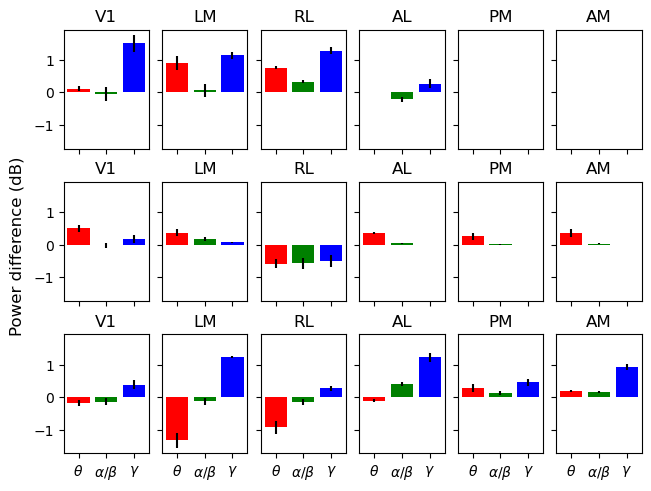

In [27]:
fig, axes = plt.subplots(nrows=len(CONTRASTS), ncols=len(anatomical_areas), sharex=True, sharey=True, layout="constrained")
fig.supylabel("Power difference (dB)")

for row, (contrast, condl, condr) in enumerate(CONTRASTS):
    for col, area in enumerate(anatomical_areas):
        axes[row, col].bar(np.arange(len(BANDS)), [band_powers[contrast][area][band].mean(axis=-1) for band in BANDS], color=['r', 'g', 'b'],
                           yerr=[2 * band_powers[contrast][area][band].std(axis=-1) / band_powers[contrast][area][band].shape[-1] for band in BANDS],
                           tick_label=[BAND_LATEX[band] for band in BANDS])
        axes[row, col].set_title(AREA_TITLES[area])

    for i, area in enumerate(anatomical_areas):
        for band in BANDS:
            logging.info("%s power in %s for contrast %s: %f" % (band, area, contrast, band_powers[contrast][area][band].mean(axis=-1)))

plt.savefig("area_contrast_powers.svg")
plt.savefig("area_contrast_powers.png")
plt.show()

INFO:root:Theta power in VISp for contrast dd: 0.113470
INFO:root:Theta power in VISl for contrast dd: 0.901171
INFO:root:Theta power in VISrl for contrast dd: 0.762675
INFO:root:Theta power in VISal for contrast dd: 0.000000
INFO:root:Theta power in VISpm for contrast dd: 0.000000
INFO:root:Theta power in VISam for contrast dd: 0.000000
INFO:root:Theta power in VISp for contrast go_contrast: 0.504746
INFO:root:Theta power in VISl for contrast go_contrast: 0.372830
INFO:root:Theta power in VISrl for contrast go_contrast: -0.589851
INFO:root:Theta power in VISal for contrast go_contrast: 0.346142
INFO:root:Theta power in VISpm for contrast go_contrast: 0.256916
INFO:root:Theta power in VISam for contrast go_contrast: 0.356333
INFO:root:Theta power in VISp for contrast ssa: -0.176629
INFO:root:Theta power in VISl for contrast ssa: -1.329200
INFO:root:Theta power in VISrl for contrast ssa: -0.934256
INFO:root:Theta power in VISal for contrast ssa: -0.112229
INFO:root:Theta power in VISpm 

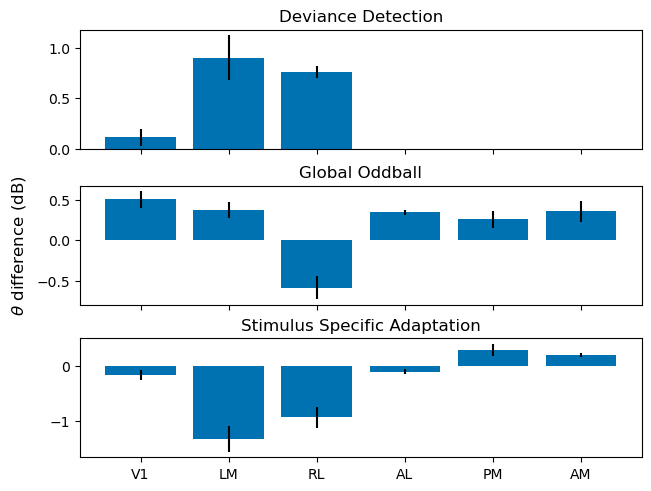

In [28]:
fig, axes = plt.subplots(nrows=len(CONTRASTS), ncols=1, sharex=True, sharey=False, layout="constrained")
fig.supylabel("$\\theta$ difference (dB)")
for row, (contrast, condl, condr) in enumerate(CONTRASTS):
    theta_contrasts = {area: band_powers[contrast][area]["Theta"] for area in anatomical_areas}
    contrast_powers = [theta_contrasts[area].mean(axis=-1) for area in anatomical_areas]
    axes[row].bar(np.arange(len(anatomical_areas)), contrast_powers,
                  yerr=[2 * theta_contrasts[area].std(axis=-1) / theta_contrasts[area].shape[-1] for area in anatomical_areas],
                  tick_label=[AREA_TITLES[area] for area in anatomical_areas])
    axes[row].set_title(CONTRAST_TITLES[contrast])

    for i, area in enumerate(anatomical_areas):
        logging.info("Theta power in %s for contrast %s: %f" % (area, contrast, contrast_powers[i]))

plt.savefig("area_theta_contrasts.svg")
plt.savefig("area_theta_contrasts.png")
plt.show()

INFO:root:Alpha/beta power in VISp for contrast dd: -0.052231
INFO:root:Alpha/beta power in VISl for contrast dd: 0.058916
INFO:root:Alpha/beta power in VISrl for contrast dd: 0.328248
INFO:root:Alpha/beta power in VISal for contrast dd: -0.219093
INFO:root:Alpha/beta power in VISpm for contrast dd: 0.000000
INFO:root:Alpha/beta power in VISam for contrast dd: 0.000000
INFO:root:Alpha/beta power in VISp for contrast go_contrast: -0.023380
INFO:root:Alpha/beta power in VISl for contrast go_contrast: 0.174964
INFO:root:Alpha/beta power in VISrl for contrast go_contrast: -0.578124
INFO:root:Alpha/beta power in VISal for contrast go_contrast: 0.046683
INFO:root:Alpha/beta power in VISpm for contrast go_contrast: 0.010607
INFO:root:Alpha/beta power in VISam for contrast go_contrast: 0.029031
INFO:root:Alpha/beta power in VISp for contrast ssa: -0.147662
INFO:root:Alpha/beta power in VISl for contrast ssa: -0.131410
INFO:root:Alpha/beta power in VISrl for contrast ssa: -0.155439
INFO:root:Al

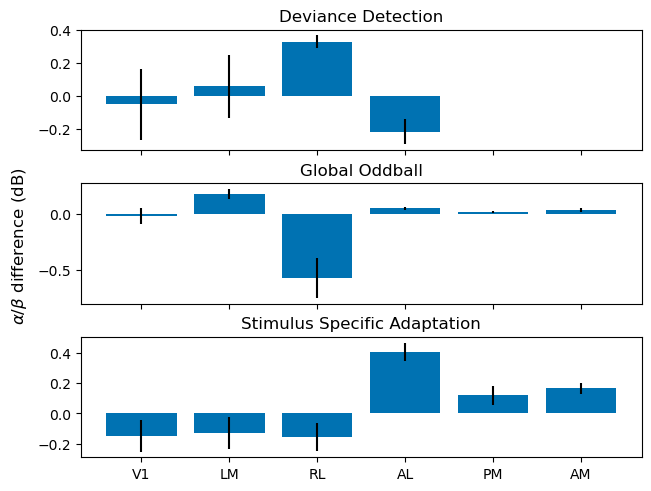

In [29]:
fig, axes = plt.subplots(nrows=len(CONTRASTS), ncols=1, sharex=True, sharey=False, layout="constrained")
fig.supylabel("$\\alpha/\\beta$ difference (dB)")
for row, (contrast, condl, condr) in enumerate(CONTRASTS):
    alphabeta_contrasts = {area: band_powers[contrast][area]["Alpha/Beta"] for area in anatomical_areas}
    contrast_powers = [alphabeta_contrasts[area].mean(axis=-1) for area in anatomical_areas]
    axes[row].bar(np.arange(len(anatomical_areas)), contrast_powers,
                  yerr=[2 * alphabeta_contrasts[area].std(axis=-1) / alphabeta_contrasts[area].shape[-1] for area in anatomical_areas],
                  tick_label=[AREA_TITLES[area] for area in anatomical_areas])
    axes[row].set_title(CONTRAST_TITLES[contrast])

    for i, area in enumerate(anatomical_areas):
        logging.info("Alpha/beta power in %s for contrast %s: %f" % (area, contrast, contrast_powers[i]))

plt.savefig("area_alphabeta_contrasts.svg")
plt.savefig("area_alphabeta_contrasts.png")
plt.show()

INFO:root:Gamma power in VISp for contrast dd: 1.507016
INFO:root:Gamma power in VISl for contrast dd: 1.136592
INFO:root:Gamma power in VISrl for contrast dd: 1.281284
INFO:root:Gamma power in VISal for contrast dd: 0.262888
INFO:root:Gamma power in VISpm for contrast dd: 0.000000
INFO:root:Gamma power in VISam for contrast dd: 0.000000
INFO:root:Gamma power in VISp for contrast go_contrast: 0.169955
INFO:root:Gamma power in VISl for contrast go_contrast: 0.070012
INFO:root:Gamma power in VISrl for contrast go_contrast: -0.502171
INFO:root:Gamma power in VISal for contrast go_contrast: 0.000000
INFO:root:Gamma power in VISpm for contrast go_contrast: 0.000000
INFO:root:Gamma power in VISam for contrast go_contrast: 0.000000
INFO:root:Gamma power in VISp for contrast ssa: 0.381049
INFO:root:Gamma power in VISl for contrast ssa: 1.239700
INFO:root:Gamma power in VISrl for contrast ssa: 0.268984
INFO:root:Gamma power in VISal for contrast ssa: 1.226783
INFO:root:Gamma power in VISpm for 

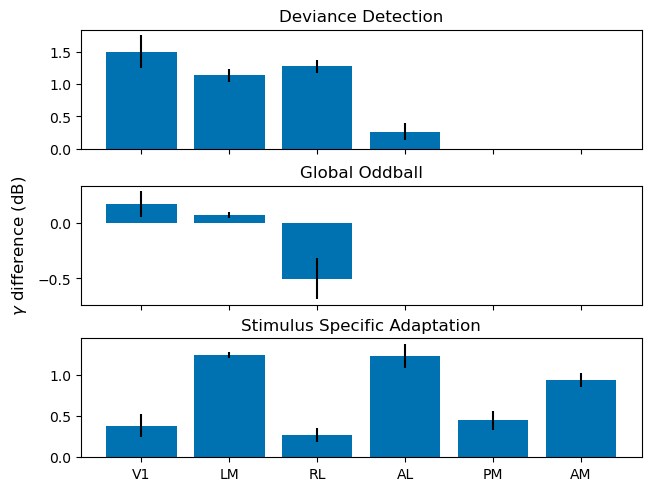

In [30]:
fig, axes = plt.subplots(nrows=len(CONTRASTS), ncols=1, sharex=True, sharey=False, layout="constrained")
fig.supylabel("$\\gamma$ difference (dB)")
for row, (contrast, condl, condr) in enumerate(CONTRASTS):
    gamma_contrasts = {area: band_powers[contrast][area]["Gamma"] for area in anatomical_areas}
    contrast_powers = [gamma_contrasts[area].mean(axis=-1) for area in anatomical_areas]
    axes[row].bar(np.arange(len(anatomical_areas)), contrast_powers,
                  yerr=[2 * gamma_contrasts[area].std(axis=-1) / gamma_contrasts[area].shape[-1] for area in anatomical_areas],
                  tick_label=[AREA_TITLES[area] for area in anatomical_areas])
    axes[row].set_title(CONTRAST_TITLES[contrast])

    for i, area in enumerate(anatomical_areas):
        logging.info("Gamma power in %s for contrast %s: %f" % (area, contrast, contrast_powers[i]))

plt.savefig("area_gamma_contrasts.svg")
plt.savefig("area_gamma_contrasts.png")
plt.show()